In [1]:
import jax
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.distributions.constraints import real
import pandas as pd

import pollux as plx
from pollux.models.transforms import LinearTransform

from process_rvs import process_spectra

jax.config.update("jax_enable_x64", True)

from matplotlib import rcParams

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)


# Getting the data ready

In [2]:
df_stars = pd.read_pickle('/Users/honeyeah/Codes/LuxProject/data/giants_rel_most_rel.pkl')
df_stars = df_stars.head(500)

In [5]:
n_all_stars = len(df_stars)
n_stars = n_all_stars  # number of simulated stars to generate in the train and test sets
labels = ['teff', 'logg', 'fe_h', 'mg_h', 'n_h', 'si_h', 'ni_h', 'ca_h', 'ce_h']
n_labels = len(labels)  # number of labels to generate per star
#n_latents = n_labels * 4  # size of the latent vector per star
n_latents = n_labels * 2
n_flux = 2401  # number of spectral flux pixels per star

rng = np.random.default_rng(seed=8675309)

A = np.zeros((n_labels, n_latents))
A[0, 0] = 1.0
A[1, 1] = 1.0

B = rng.normal(scale=0.1, size=(n_flux, n_latents))
B[:, 0] = B[:, 0] + 4 * np.exp(-0.5 * (np.arange(n_flux) - n_flux / 2) ** 2 / 5**2)
B[:, 1] = B[:, 1] + 2 * np.exp(-0.5 * (np.arange(n_flux) - n_flux / 4) ** 2 / 3**2)

In [4]:
print("Number of all stars = ", len(df_stars))
df_stars = df_stars[:n_stars]
print("Number of stars in our set = ", len(df_stars))
df_stars.head(1)

Number of all stars =  500
Number of stars in our set =  500


,source_id,flux,flux_error,teff,e_teff,logg,e_logg,n_h,e_n_h,mg_h,...,si_h,e_si_h,fe_h,e_fe_h,ni_h,e_ni_h,ca_h,e_ca_h,ce_h,e_ce_h
0,4664665578195665280,"[--, --, 0.9704861, 0.97988486, 0.97052944, 0....","[--, --, 0.01576104, 0.00933747, 0.006561436, ...",4707.933105,3.487,2.45,0.008,-0.151,0.002828,-0.064,...,-0.104,0.002236,-0.344,0.001,-0.185,0.001,-0.174,0.002236,-0.416,0.001


In [6]:
# List of error column names corresponding to labels
params_errors = [f"e_{p}" if not p.startswith('e_') else p for p in labels]

# Stack columns for labels
df_stars_labels = np.column_stack([df_stars[p] for p in labels])

# Stack columns for errors
df_stars_label_errs = np.column_stack([df_stars[e] for e in params_errors])

df_stars_labels.shape

(500, 9)

In [7]:
df_stars = df_stars.reset_index(drop=True)

In [8]:
fluxes_with_ca_mask = []
flux_errs_with_ca_mask = []

lambdas = np.linspace(846, 870, 2401)

for i in range(len(df_stars['flux'])):
	flux_single,flux_err_single = process_spectra(lambdas,df_stars['flux'].iloc[i],df_stars['flux_error'].iloc[i])

	fluxes_with_ca_mask.append(flux_single)
	flux_errs_with_ca_mask.append(flux_err_single)

In [9]:
stars_dict = {
    'label': df_stars_labels,
    'label_err': df_stars_label_errs,
    'flux': fluxes_with_ca_mask,
    'flux_err': flux_errs_with_ca_mask
}

In [13]:
flux, flux_err = process_spectra(lambdas, df_stars['flux'][0], df_stars['flux_error'][0])

In [14]:
stars_dict['flux'] = np.vstack([f.filled(1) if isinstance(f, np.ma.MaskedArray) else f
                              for f in stars_dict['flux']])

# Convert flux_err list to 2D array
stars_dict['flux_err'] = np.vstack([f.filled(9999) if isinstance(f, np.ma.MaskedArray) else f
                                  for f in stars_dict['flux_err']])

To use this data with the {py:class}`~pollux.models.LuxModel`, we will need to define a {py:class}`~pollux.data.PolluxData` instance. This object acts as a container for the data and uncertainties, and also provides a mechanism to define "pre-processors" for the data. In this case, we will define pre-processors that normalize the labels and spectra to have zero mean and unit variance:

In [15]:
all_data = plx.data.PolluxData(
    flux=plx.data.OutputData(
        stars_dict["flux"],
        err=stars_dict["flux_err"],
        preprocessor=plx.data.ShiftScalePreprocessor.from_data(stars_dict["flux"]),
    ),
    label=plx.data.OutputData(
        stars_dict["label"],
        err=stars_dict["label_err"],
        preprocessor=plx.data.ShiftScalePreprocessor.from_data(stars_dict["label"]),
    ),
)

preprocessed_data = all_data.preprocess()

In [16]:
train_data = preprocessed_data[: n_stars // 2]
test_data = preprocessed_data[n_stars // 2 :]
len(train_data), len(test_data)

(250, 250)

# Construct Lux model

In [17]:
model = plx.LuxModel(latent_size=n_latents)

In [18]:
print(all_data.keys())  # noqa: T201
model.register_output("label", LinearTransform(output_size=n_labels))
model.register_output("flux", LinearTransform(output_size=n_flux))

dict_keys(['flux', 'label'])


In [19]:
rngs = jax.random.split(jax.random.PRNGKey(42), 3)

## Optimizing the model with training data (i.e. training the model)

# 1) Adams

In [22]:
import time
t0 = time.time()
opt_pars_svi, svi_results = model.optimize(
    train_data,
    rng_key=jax.random.PRNGKey(112358),
    optimizer=numpyro.optim.Adam(1e-3),
    num_steps=10_000,
    svi_run_kwargs={"progress_bar": False},
)
svi_results.losses.block_until_ready()
svi_time = time.time() - t0
print(f"SVI optimization time: {svi_time:.2f} seconds")

SVI optimization time: 12.13 seconds


# 2) iterative_opt

In [23]:
t0 = time.time()
iterative_result = model.optimize_iterative(
    train_data,
    max_cycles=50,
    tol=1e-6,
    rng_key=jax.random.PRNGKey(112358),
    progress=False,
)

iterative_time = time.time() - t0
print(f"Iterative optimization time: {iterative_time:.2f} seconds")
print(
    f"Converged: {iterative_result.converged} after {iterative_result.n_cycles} cycles"
)

Iterative optimization time: 1.23 seconds
Converged: False after 50 cycles


Text(0.5, 0.98, 'Convergence Comparison')

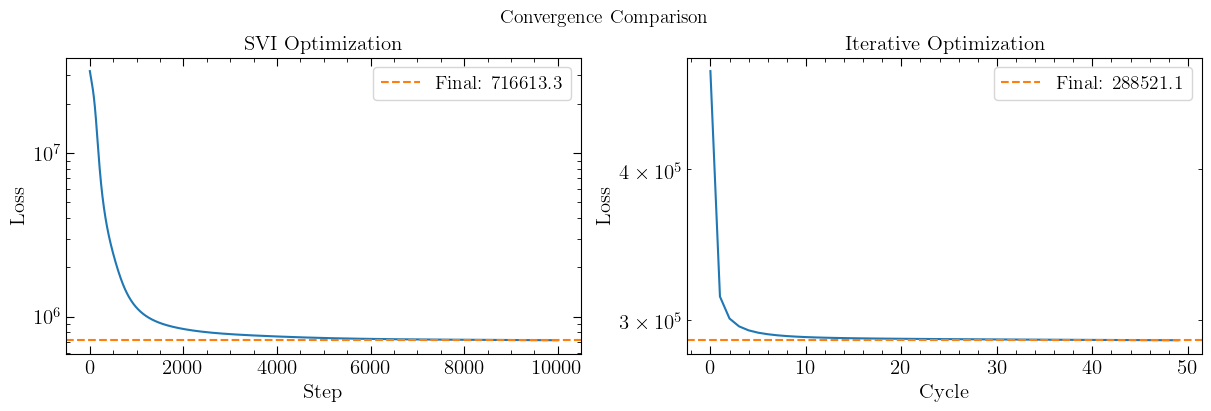

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")

# SVI loss trajectory
axes[0].semilogy(svi_results.losses)
axes[0].set(xlabel="Step", ylabel="Loss", title="SVI Optimization")
axes[0].axhline(
    svi_results.losses[-1],
    color="tab:orange",
    ls="--",
    label=f"Final: {svi_results.losses[-1]:.1f}",
)
axes[0].legend()

# Iterative loss trajectory
axes[1].semilogy(iterative_result.losses_per_cycle)
axes[1].set(xlabel="Cycle", ylabel="Loss", title="Iterative Optimization")
axes[1].axhline(
    iterative_result.losses_per_cycle[-1],
    color="tab:orange",
    ls="--",
    label=f"Final: {iterative_result.losses_per_cycle[-1]:.1f}",
)
axes[1].legend()

plt.suptitle("Convergence Comparison", fontsize=14)

In [25]:
# Create fixed_pars containing the trained model parameters (everything except latents)
fixed_pars_svi = {k: v for k, v in opt_pars_svi.items() if k != "latents"}

# Create test data with only flux (we want to predict labels using only flux)
test_flux_only = plx.data.PolluxData(flux=test_data["flux"])

# Optimize latents for test set using SVI (fix model parameters)
# Use names=["flux"] to only model the flux output (since we don't have label data)
test_pars_svi, _ = model.optimize(
    test_flux_only,
    rng_key=jax.random.PRNGKey(42),
    optimizer=numpyro.optim.Adam(1e-3),
    num_steps=2000,
    fixed_pars=fixed_pars_svi,
    names=["flux"],
    svi_run_kwargs={"progress_bar": False},
)
# Merge the fixed parameters back with the optimized latents
test_pars_svi = {**fixed_pars_svi, **test_pars_svi}

In [26]:
from pollux.models.iterative import ParameterBlock

opt_pars_iter = iterative_result.params
fixed_pars_iter = {k: v for k, v in opt_pars_iter.items() if k != "latents"}

# Optimize latents for test set using iterative method
# Only optimize latents (not output parameters) since we're using fixed trained params
# Pass initial_params with the trained A matrices and zero latents
initial_test_pars = {
    **fixed_pars_iter,
    "latents": jnp.zeros((len(test_flux_only), model.latent_size)),
}
test_blocks = [ParameterBlock("latents", "latents", optimizer="least_squares")]
test_result_iter = model.optimize_iterative(
    test_flux_only,
    blocks=test_blocks,
    max_cycles=50,
    tol=1e-6,
    initial_params=initial_test_pars,
    progress=False,
)
# Merge trained output params with optimized test latents
test_pars_iter = {**fixed_pars_iter, "latents": test_result_iter.params["latents"]}

In [27]:
# Predictions on test set from both methods
pred_svi = model.predict_outputs(test_pars_svi["latents"], test_pars_svi)
pred_iter = model.predict_outputs(test_pars_iter["latents"], test_pars_iter)

Text(0.5, 0.98, 'Test Set: Predicted vs. True Labels')

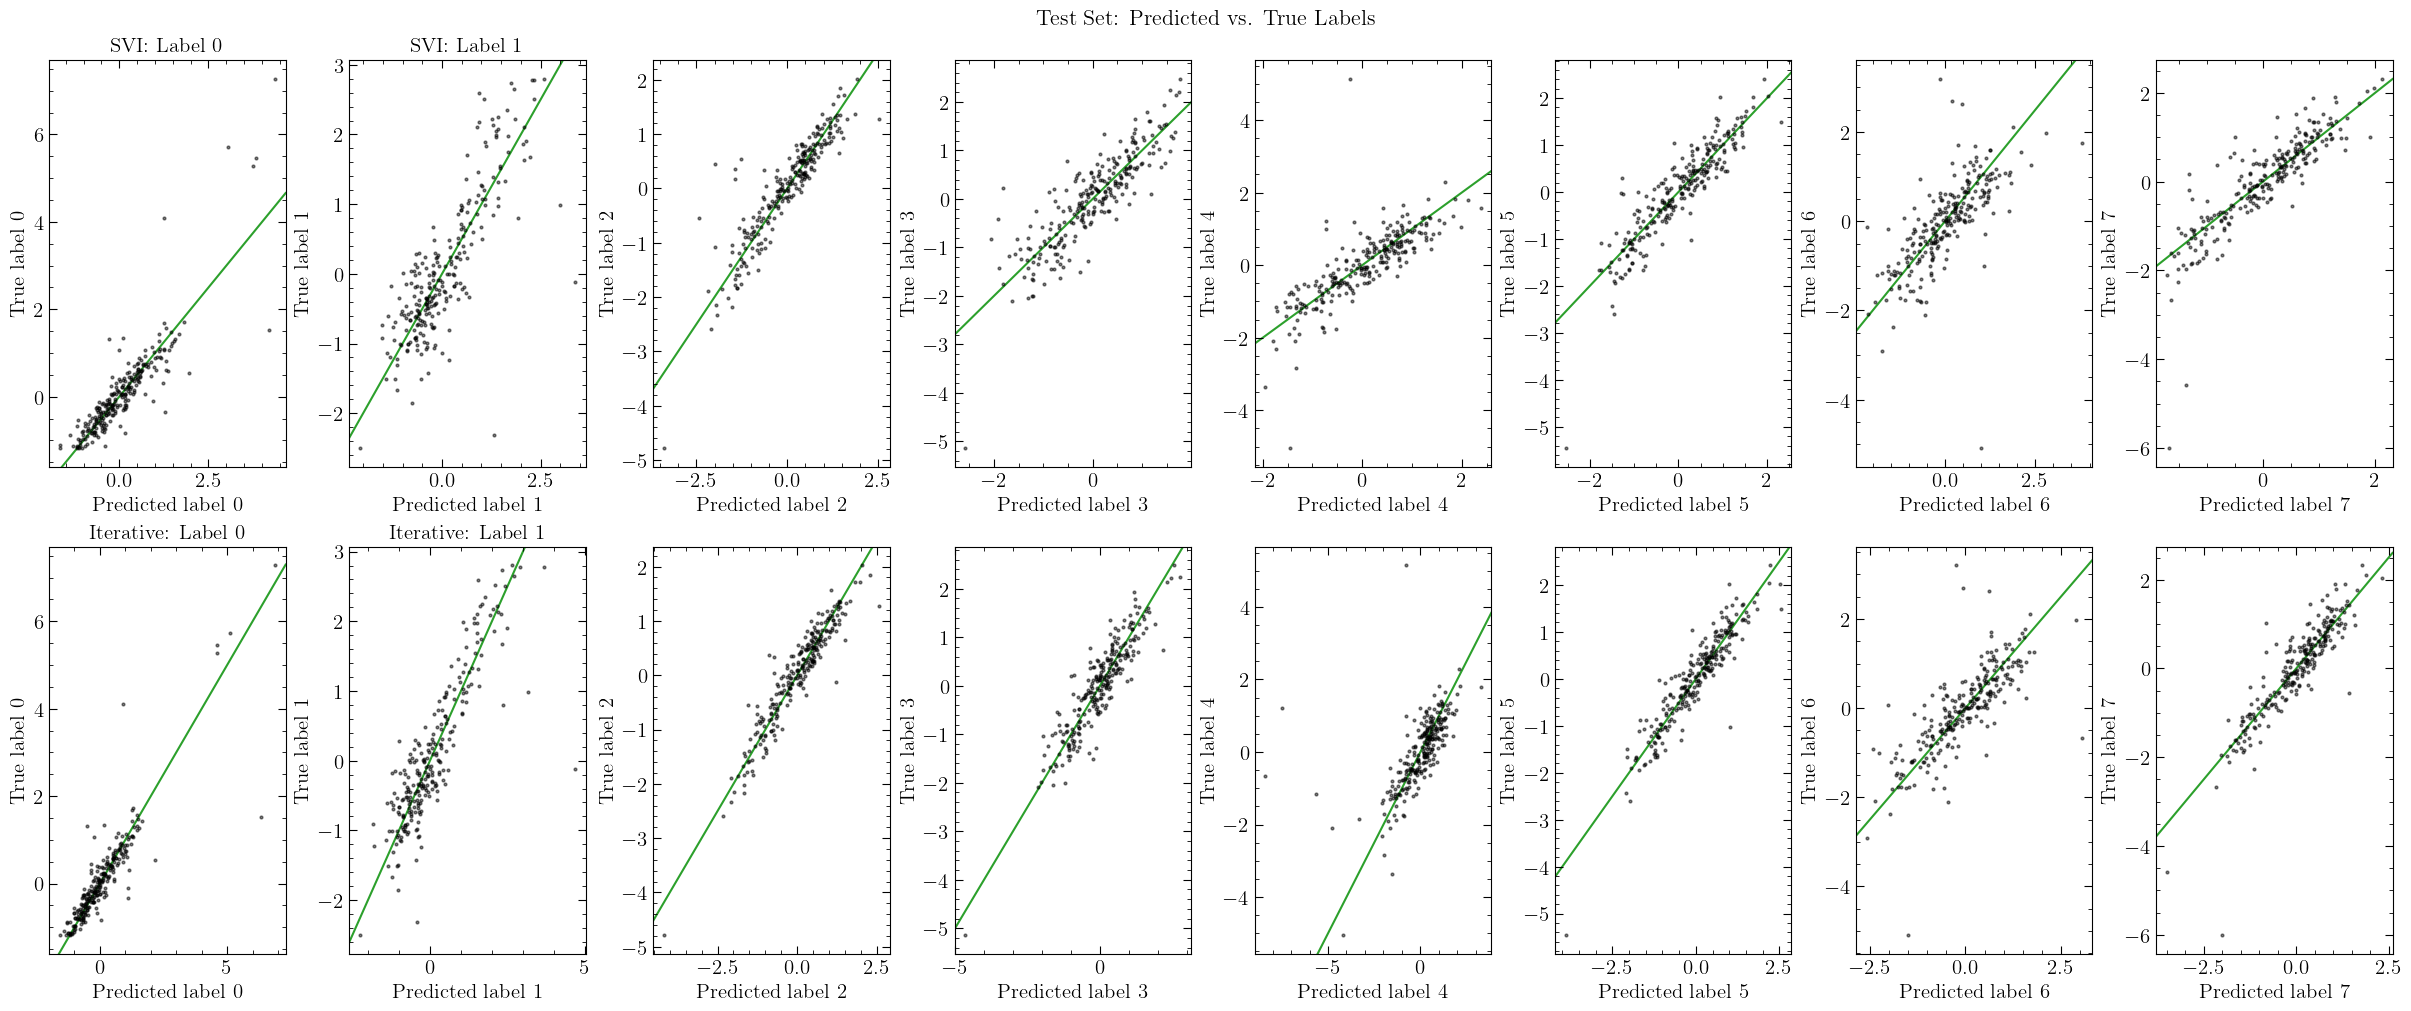

In [33]:
pt_style = {"ls": "none", "ms": 2.0, "alpha": 0.5, "marker": "o", "color": "k"}

fig, axes = plt.subplots(2, 8, figsize=(24, 10), layout="constrained")

# Top row: SVI predictions vs true
for i in range(8):
    axes[0, i].plot(pred_svi["label"][:, i], test_data["label"].data[:, i], **pt_style)
    axes[0, i].set(xlabel=f"Predicted label {i}", ylabel=f"True label {i}")
    axes[0, i].axline([0, 0], slope=1, color="tab:green", zorder=-100)
axes[0, 0].set_title("SVI: Label 0")
axes[0, 1].set_title("SVI: Label 1")

# Bottom row: Iterative predictions vs true
for i in range(8):
    axes[1, i].plot(pred_iter["label"][:, i], test_data["label"].data[:, i], **pt_style)
    axes[1, i].set(xlabel=f"Predicted label {i}", ylabel=f"True label {i}")
    axes[1, i].axline([0, 0], slope=1, color="tab:green", zorder=-100)
axes[1, 0].set_title("Iterative: Label 0")
axes[1, 1].set_title("Iterative: Label 1")

fig.suptitle("Test Set: Predicted vs. True Labels", fontsize=16)

In [34]:
# Compute prediction errors on test set
svi_label_rmse = np.sqrt(np.mean((pred_svi["label"] - test_data["label"].data) ** 2))
iter_label_rmse = np.sqrt(np.mean((pred_iter["label"] - test_data["label"].data) ** 2))

svi_flux_rmse = np.sqrt(np.mean((pred_svi["flux"] - test_data["flux"].data) ** 2))
iter_flux_rmse = np.sqrt(np.mean((pred_iter["flux"] - test_data["flux"].data) ** 2))

print("Test Set Performance Comparison")
print("=" * 50)
print(f"{'Method':<20} {'Time (s)':<12} {'Label RMSE':<15} {'Flux RMSE':<15}")
print("-" * 50)
print(
    f"{'SVI (10k steps)':<20} {svi_time:<12.2f} {svi_label_rmse:<15.4f} {svi_flux_rmse:<15.4f}"
)
print(
    f"{'Iterative':<20} {iterative_time:<12.2f} {iter_label_rmse:<15.4f} {iter_flux_rmse:<15.4f}"
)

Test Set Performance Comparison
Method               Time (s)     Label RMSE      Flux RMSE      
--------------------------------------------------
SVI (10k steps)      12.13        0.5799          0.7522         
Iterative            1.23         0.5927          0.7399         
